In [115]:
## Firstly try to do PCA for FPOCalCu, then do a LM to verify stats
## Secondly try to do PCA for all regions to see if interesting regions show up
## Some experiments with automatic parameter selection

In [116]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.formula.api as smf
import os

In [117]:
curProject = 'ataxia'
curRoot = 'C'  # 'C' or 'D'

In [118]:
#######################   read in all_DB_info csv   ########################
infoBaselineName = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\processed_INFO\ATRIL_BIOSCA_CERMOI_time1_only.csv'
Atril_Biosca_Cermoi_INFO = pd.read_csv(infoBaselineName,index_col=0,header=0)

#print("combined_iso_u columns:", combined_iso_u.columns.tolist())
print("INFO columns:", Atril_Biosca_Cermoi_INFO.columns.tolist())

### verification of column names ###
#one_iso_u_name = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_iso_u\FColl-SRh_left_name06-43-43--210_embeddings_iso_u.csv'
#one_combined_iso_u = pd.read_csv(one_iso_u_name,index_col=0,header=0)
#print("region columns:", one_combined_iso_u.columns.tolist())

INFO columns: ['RANDOMIZATION', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS', 'CodeICM', 'Age_onset', 'CCFS', 'Handedness', 'Disease_duration', 'allele1', 'allele2', 'minAllele', 'maxAllele', 'sumAllele']


In [119]:
#######################################  performing PCA  #########################################
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def perform_pca(dist_df, numDim):
    """
    Performs PCA on a dataframe of descriptors. 
    Always uses Euclidean distance by its nature, highly stable for small samples.
    """
    subjNames = dist_df.index
    dimNames = np.arange(1, numDim + 1)
    columns = [f"pca_dim{i}" for i in dimNames]
    
    # Standardize the data (Crucial for PCA), each of the descriptors has a mean of 0 and variance of 1
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(dist_df.values)
    
    # Initialize and Run PCA
    pca_model = PCA(n_components=numDim)
    pca_values = pca_model.fit_transform(X_scaled)
    
    # Create DataFrame
    pca_DF = pd.DataFrame(pca_values, index=subjNames, columns=columns)
    
    # Attach metadata: Explained Variance Ratio, how much "information" is captured in the numDim dimensions
    explained_var = pca_model.explained_variance_ratio_.sum()
    pca_DF.attrs['explained_variance'] = explained_var
    
    print(f"Total Explained Variance (3 dims): {explained_var:.2%}")
    
    return pca_DF

In [171]:
##############  projecting target_matrix into the PCA space of the refernece_matrix  ################

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def project_to_pca_space(reference_matrix, target_matrix, n_components=6):
    """
    Creates a PCA space from a reference set (e.g., Study 1 + 2) 
    and projects a new set (e.g., Study 3) into that same space.
    
    Parameters:
    -----------
    reference_matrix : np.array (Samples x Features)
        The data used to 'build' the PCA coordinate system.
    target_matrix : np.array (Samples x Features)
        The new data to be projected into the established system.
    n_components : int
        Number of PCA dimensions to return.
        
    Returns:
    --------
    ref_pca : np.array
        Reference data in the new PCA space.
    target_pca : np.array
        Target data projected into the same PCA space.
    pca_model : sklearn.decomposition.PCA
        The fitted PCA object (useful for checking explained variance).
    """
    columns = [f'pca_dim{i+1}' for i in range(n_components)]
    
    # 1. Scaling is crucial for PCA
    scaler = StandardScaler()
    # Fit the scaler ONLY on the reference data
    ref_scaled = scaler.fit_transform(reference_matrix)
    # Apply the SAME scaling to the target data
    target_scaled = scaler.transform(target_matrix)
    
    # 2. Initialize and Fit PCA on the reference data
    pca = PCA(n_components=n_components)
    ref_pca = pca.fit_transform(ref_scaled)
    ref_pca_DF = pd.DataFrame(ref_pca, index=reference_matrix.index, columns=columns)
    
    # 3. Project target data into the EXISTING PCA space
    # IMPORTANT: We use .transform(), NOT .fit_transform() here
    target_pca = pca.transform(target_scaled)
    target_pca_DF = pd.DataFrame(target_pca, index=target_matrix.index, columns=columns)
    
    return ref_pca_DF, target_pca_DF, pca

In [205]:
#########################  merging the above two functions into one  ##########################

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def run_pca_workflow(ref_df, target_df=None, n_components=6):
    """
    Unified PCA handler. 
    If target_df is None: Performs standard PCA on ref_df.
    If target_df exists: Fits PCA on ref_df and projects target_df into that space.
    """
    # 0. ENSURE COLUMN ALIGNMENT (The silent PCA killer)
    # This ensures Feature A is always in the same 'slot'
    ref_df = ref_df.sort_index(axis=1)
    
    columns = [f'pca_dim{i+1}' for i in range(n_components)]
    
    # 1. Scaling - Always fit only on the Reference
    scaler = StandardScaler()
    ref_scaled = scaler.fit_transform(ref_df)
    
    # 2. PCA Fit - Always fit only on the Reference
    pca_model = PCA(n_components=n_components)
    ref_pca_vals = pca_model.fit_transform(ref_scaled)
    
    # Convert to DataFrame
    ref_pca_df = pd.DataFrame(ref_pca_vals, index=ref_df.index, columns=columns)
    
    # 3. Handle Projection (if target exists)
    if target_df is not None:
        print('Target_df not None, calculating projection!')
        target_df = target_df.sort_index(axis=1) # Sort columns to match ref
        target_scaled = scaler.transform(target_df) # Use ref's scaler
        target_pca_vals = pca_model.transform(target_scaled) # Use ref's PCA
        
        target_pca_df = pd.DataFrame(target_pca_vals, index=target_df.index, columns=columns)
        
        # Combine them
        combined_pca = pd.concat([ref_pca_df, target_pca_df])
        return combined_pca, pca_model
    
    return ref_pca_df, pca_model

In [129]:
##########################  Define subject lists for distance selection  #############################

# 1. Get the relevant subjects
sca_1_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 1) | \
            ((Atril_Biosca_Cermoi_INFO['SCA'] == 0) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'BIOSCA'))
sca_2_ctl = ((Atril_Biosca_Cermoi_INFO['SCA'] == 2) & (Atril_Biosca_Cermoi_INFO['CodeICM'] != 'ATRIL')) | \
            (Atril_Biosca_Cermoi_INFO['SCA'] == 0) 
sca_2_ctl_with_Atril = (Atril_Biosca_Cermoi_INFO['SCA'] == 2) | (Atril_Biosca_Cermoi_INFO['SCA'] == 0) 
sca_3_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 3) | \
            ((Atril_Biosca_Cermoi_INFO['SCA'] == 0) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'BIOSCA'))
sca_7_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 7) | (Atril_Biosca_Cermoi_INFO['SCA'] == 0) 

# 2. Use the condition to get the index (subject names)
subjects_sca_1_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_1_ctl].index.tolist()
#print(subjects_sca_1_ctl)
subjects_sca_2_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_2_ctl].index.tolist()
print(subjects_sca_2_ctl)
subjects_sca_2_ctl_with_Atril = Atril_Biosca_Cermoi_INFO.loc[sca_2_ctl_with_Atril].index.tolist()
print(subjects_sca_2_ctl_with_Atril
     )
subjects_sca_3_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_3_ctl].index.tolist()
#print(subjects_sca_3_ctl)
subjects_sca_7_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_7_ctl].index.tolist()
#print(subjects_sca_7_ctl)


['001012FJ', '001015VJ', '001017VP', '001019DA', '001020HG', '001021CJ', '001022LM', '001025LJ', '001027RY', '001032SG', '001037GA', '001040BF', '001045PB', '001046CJ', '001049BD', '001054MP', '001055JC', '001057MB', '001058FG', '001059MV', '001060MJ', '001065BC', '001073PM', '001075HJ', '001078PM', '001079LP', '001085BN', '001086CP', '001091MR', '001099GL', '001100PY', '001101JO', '00001PJ', '00002PV', '00004PA', '00007OP', '00008CJ', '00009LN', '00011EG', '00012BM', '00017ML', '00019RP', '00020CT', '00021JA', '00022DA', '00023EA', '00025AY', '00026AD', '00027EF', '00029DP', '00030CA', '00031CP', '00032DL', '00035NR', '00036DC', '00037CI', '00039OV']
['0010001OP', '0010002MV', '0010003CJ', '0010004HV', '0010005BC', '0010006OG', '0010007MA', '0010008CT', '0010009BJ', '0010010DM', '0010011CP', '0010012MC', '0010013AN', '0010014MM', '0010015BV', '0010016VP', '0010017MD', '0010018RE', '0010019MM', '0010020PA', '0010021MA', '0010022MB', '0010023MM', '0010024VN', '0010025RA', '0010026DA', '

In [137]:
## Adding the definition of ONLY the ATRIL SCA2 subjects
sca_2_ATRIL = (Atril_Biosca_Cermoi_INFO['SCA'] == 2) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'ATRIL')
matches = Atril_Biosca_Cermoi_INFO[sca_2_ATRIL]
#print(matches)
print(f"Number of matches found: {len(matches)}")

subjects_sca_2_ATRIL = Atril_Biosca_Cermoi_INFO.loc[sca_2_ATRIL].index.tolist()
print(subjects_sca_2_ATRIL)

Number of matches found: 45
['0010001OP', '0010002MV', '0010003CJ', '0010004HV', '0010005BC', '0010006OG', '0010007MA', '0010008CT', '0010009BJ', '0010010DM', '0010011CP', '0010012MC', '0010013AN', '0010014MM', '0010015BV', '0010016VP', '0010017MD', '0010018RE', '0010019MM', '0010020PA', '0010021MA', '0010022MB', '0010023MM', '0010024VN', '0010025RA', '0010026DA', '0020001GC', '0020002HP', '0030001SC', '0030002TS', '0030003BM', '0040001LN', '0040002LK', '0050001EA', '0050002BA', '0050003RF', '0060001PJ', '0060002JC', '0080001MA', '0080002SH', '0090001TT', '0090002LL', '0090003LJ', '0090004JP', '0090005TM']


In [203]:
##########################  perform PCA and write out two versions, with and without the info  ########################
regions = ["FPO-SCu-ScCal_right_name07-15-26--174_embeddings"]
#regions = ["FPO-SCu-ScCal_left_name07-13-21--118_embeddings"]
sca = 202
perform_pca_all_together = False
perform_pca_by_sca = False
perform_pca_projection = True

if sca == 1:
    subjects_select = subjects_sca_1_ctl
if sca == 2:
    subjects_select = subjects_sca_2_ctl
if sca == 3:
    subjects_select = subjects_sca_3_ctl
if sca == 7:
    subjects_select = subjects_sca_7_ctl  
if sca == 102:
    subjects_select = subjects_sca_2_ctl_with_Atril   
if sca == 202:
    base_subjects_select = subjects_sca_2_ctl 
    projection_subjects_select = subjects_sca_2_ATRIL  

infoBaselineName = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\processed_INFO\ATRIL_BIOSCA_CERMOI_time1_only.csv'
Atril_Biosca_Cermoi_INFO = pd.read_csv(infoBaselineName,index_col=0,header=0)
for curRegion in regions:
    dist_Atril, dist_Biosca, dist_Cermoi = None, None, None    
    distance_path_Atril = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril\{curRegion}.csv'
    distance_path_Biosca = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Biosca\{curRegion}.csv'
    distance_path_Cermoi = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Cermoi\{curRegion}.csv'

    ###########  file names for all SCA together  ###########
    if perform_pca_all_together:
        combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_all.csv'
        combined_pca_INFO_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_INFO.csv'
    ###########  file names for seperating SCAs  ###########    
    if not perform_pca_all_together & sca != 202:
        combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_select_{sca}.csv'
        combined_pca_INFO_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_select_{sca}_INFO.csv'
    ###########  file names for projection, seperating SCAs  ###########
    if not perform_pca_all_together & sca == 202:
        combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_project_2AtrilToRest.csv'
        combined_pca_INFO_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2AtrilToRest_INFO.csv'

    print(combined_pca_fileName)
    print(combined_pca_INFO_fileName)

    try:
        dist_Atril = pd.read_csv(distance_path_Atril, index_col=0, header=0)
        dist_Biosca = pd.read_csv(distance_path_Biosca, index_col=0, header=0)
        dist_Cermoi = pd.read_csv(distance_path_Cermoi, index_col=0, header=0)
        dist_Atril_Biosca_Cermoi = pd.concat([dist_Atril, dist_Biosca, dist_Cermoi], axis=0)
    except FileNotFoundError as e:
        print(f"Error: {e}")

    #############################  general, NOT SCA-specific  #############################
    if perform_pca_all_together:
        # perform pca on all subjects and write out
        pca_select = perform_pca(dist_Atril_Biosca_Cermoi,6)

    #############################  SCA-specific  #############################
    if perform_pca_by_sca:
        valid_subjects = dist_Atril_Biosca_Cermoi.index.intersection(subjects_select)
        dist_select = dist_Atril_Biosca_Cermoi.loc[valid_subjects,]
        #pca_select = perform_pca(dist_select,6)
        ref_pca_df, pca_model = run_pca_workflow(ref_df=dist_select, target_df=None, n_components=6)
        pca_select = ref_pca_df

    #############################  projection SCA-specific  #############################
    if perform_pca_projection:
        base_subjects = dist_Atril_Biosca_Cermoi.index.intersection(base_subjects_select)
        projection_subjects = dist_Atril_Biosca_Cermoi.index.intersection(projection_subjects_select)
        base_dist_select = dist_Atril_Biosca_Cermoi.loc[base_subjects,]
        projection_dist_select = dist_Atril_Biosca_Cermoi.loc[projection_subjects,]
#        ref_pca_df, target_pca_df, pca_model = project_to_pca_space(
#            reference_matrix=base_dist_select, 
#            target_matrix=projection_dist_select, 
#            n_components=6
#        )
#        pca_select = pd.concat([ref_pca_df, target_pca_df])
        ref_pca_df, pca_model = run_pca_workflow(ref_df=base_dist_select, target_df=projection_dist_select, n_components=6)
        pca_select = ref_pca_df

    ###############################  write out values with and without info  ###############################
    combined_pca_INFO = pd.merge(pca_select, Atril_Biosca_Cermoi_INFO, left_index=True, right_index=True)
    pca_select.to_csv(combined_pca_fileName,index_label='subjID')
    combined_pca_INFO.to_csv(combined_pca_INFO_fileName,index_label='subjID')


C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca\FPO-SCu-ScCal_right_name07-15-26--174_embeddings_pca_project_2AtrilToRest.csv
C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\FPO-SCu-ScCal_right_name07-15-26--174_embeddings_pca_2AtrilToRest_INFO.csv
target_df not None!


In [223]:
################################  LM tests, parametric  #################################
#curRegion = "FPO-SCu-ScCal_left_name07-13-21--118_embeddings"
curRegion = "FPO-SCu-ScCal_right_name07-15-26--174_embeddings"

#inName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_select_2_INFO.csv'
inName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2AtrilToRest_INFO.csv'
cur_info = pd.read_csv(inName,index_col=0,header=0)
#cur_info = combined_pca_select_INFO  # if already loaded above
cur_info_patient = cur_info[cur_info['SCA'] != 0]

diag_measures = ['SCA']   ###  Change the formula !!!
#diag_measures = ['SARA']
#diag_measures = ['CAG','SARA','INAS']
shape_measures = ['pca_dim1','pca_dim2','pca_dim3','pca_dim4','pca_dim5','pca_dim6']
#shape_measures = ['CAG']

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for diag_measure in diag_measures:
        
        #formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex)'               # for categorical diag_measure !
        formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex) + C(CodeICM)'  # for categorical diag_measure and multi-centered !        
        #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + C(CodeICM) + SARA'   
        #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + C(CodeICM)'   
       
        model = smf.ols(formula, data=cur_info).fit()
        #model = smf.ols(formula, data=cur_info_patient).fit()
        
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
        print(model.summary())
        print('\n')

        print("\nFull precision p-values:")
        for param, pval in model.pvalues.items():
            print(f"{param}: {pval:.16f}")   # 16 decimal places (full float precision)
        
        print('\n')

========================= Results for pca_dim1 and SCA ===========================
                            OLS Regression Results                            
Dep. Variable:               pca_dim1   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.7917
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.558
Time:                        17:14:43   Log-Likelihood:                -237.05
No. Observations:                  96   AIC:                             486.1
Df Residuals:                      90   BIC:                             501.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

Saving to: C:\B_projWIP\proj_ataxia\Champollion\Plots\Champollion_FPOCalCuLEFT_SCA2_pcaDim3_CAG_Scatter.png


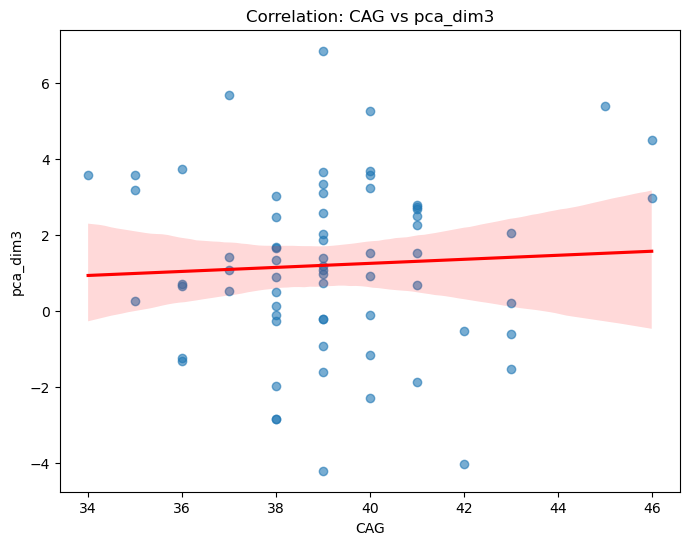

In [217]:
############################  scatter plot of correlations  ############################
cur_data = cur_info.copy()  ## cur_info defined above
cur_data_patient = cur_data[cur_data['SCA'] != 0]

class_variable = 'CAG'  # Independent Variable (X)
curX = 'pca_dim3' #'iso_dim1_neig5' # Dependent Variable (Y)

# Use regplot to get the scatter points PLUS a regression line
plt.figure(figsize=(8, 6))
sns.regplot(data=cur_data_patient, x=class_variable, y=curX, 
            scatter_kws={'alpha':0.6}, 
            line_kws={'color':'red'})

# Dynamic title based on your variables
plt.title(f'Correlation: {class_variable} vs {curX}')

#curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_Calc_SCA2_isoDim3Neig5_Manhattan_Scatter.png'
curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_FPOCalCuLEFT_SCA2_pcaDim3_CAG_Scatter.png'
print(f"Saving to: {curPlotName}")

# Uncomment these to save
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.show() # Recommended to see it before closing
#plt.close()

C:\Users\joyca\AppData\Local\Temp\ipykernel_28108\1381137791.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\B_projWIP\proj_ataxia\Champollion\Plots\Champollion_FPOCalCu_SCA2_pcaDim3_projAtrilToSca2Ctl.png


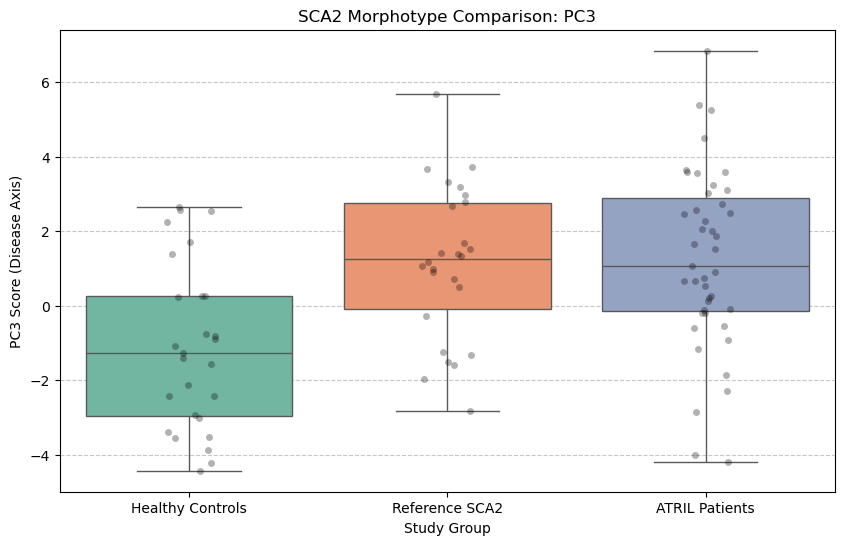

In [237]:
############################  boxplot for SCA of old pca and new projection  ############################
inName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2AtrilToRest_INFO.csv'
cur_info = pd.read_csv(inName,index_col=0,header=0)
combined_pca_INFO = cur_info.copy()  

#######################  Define the logic for the three groups  #########################
combined_pca_INFO['PlotGroup'] = 'Other'    # Start with a column of 'Other' or NaNs
# Group A: ATRIL (Patients)
mask_atril = combined_pca_INFO['CodeICM'] == 'ATRIL'
combined_pca_INFO.loc[mask_atril, 'PlotGroup'] = 'ATRIL Patients'
# Group B: Controls (SCA == 0)
mask_control = combined_pca_INFO['SCA'] == 0
combined_pca_INFO.loc[mask_control, 'PlotGroup'] = 'Healthy Controls'
# Group C: Reference SCA2 (SCA == 2 but not ATRIL)
mask_ref_sca2 = (combined_pca_INFO['SCA'] == 2) & (combined_pca_INFO['CodeICM'] != 'ATRIL')
combined_pca_INFO.loc[mask_ref_sca2, 'PlotGroup'] = 'Reference SCA2'

######################  Filter out the 'Other' rows if any remain  ######################
plot_df = combined_pca_INFO[combined_pca_INFO['PlotGroup'] != 'Other'].copy()

#################################  Create the Boxplot  ###################################
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_df, 
    x='PlotGroup', 
    y='pca_dim3', 
    order=['Healthy Controls', 'Reference SCA2', 'ATRIL Patients'], # Controls the sequence
    palette='Set2'
)

##################  Add individual points on top to see the distribution (stripplot)  ####################
sns.stripplot(
    data=plot_df, 
    x='PlotGroup', 
    y='pca_dim3', 
    order=['Healthy Controls', 'Reference SCA2', 'ATRIL Patients'],
    color='black', 
    alpha=0.3
)
plt.title('SCA2 Morphotype Comparison: PC3')
plt.ylabel('PC3 Score (Disease Axis)')
plt.xlabel('Study Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
#plt.show()


curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_FPOCalCu_SCA2_pcaDim3_projAtrilToSca2Ctl.png'
print(curPlotName)
plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.close()

In [ ]:
##############################   WIP: automatic parameter selection  ################################

In [ ]:
##########  WIP....check the reconstruction error of the three types of distances  ##########

metrics = ['euclidean', 'manhattan', 'cosine']
for m in metrics:
    result_df = perform_isomap(data_df, 2, 5, metric=m)
    error = result_df.attrs['reconstruction_error']
    print(f"Metric: {m} | Reconstruction Error: {error:.4f}")

In [ ]:
###################  construct latent_dict  ####################
inPath = rf"\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_iso_u"
region_list = [] # the 15 relevant regions

In [ ]:
#######################  parameter selection  ########################

regions_list = ['FPO-SCu-ScCal_right_name07-15-26--174_embeddings_iso_u']
results = {}

for region in regions_list:
    # 1. Get data for this region (Subjects x 32)
    data = latent_dict[region] 
    
    # 2. Secondary Embedding (Double Embedding)
    primary_dist = pairwise_distances(data, metric='cosine')
    secondary_dist = pairwise_distances(primary_dist, metric='euclidean')
    
    # 3. Test PCA (PCoA) vs Isomap
    pca_coords = PCA(n_components=2).fit_transform(secondary_dist)
    iso_coords = Isomap(n_neighbors=10, metric='precomputed').fit_transform(secondary_dist)
    
    # 4. Score them
    score_pca = silhouette_score(pca_coords, labels)
    score_iso = silhouette_score(iso_coords, labels)
    
    # 5. Automated Choice
    if score_iso > score_pca:
        final_coords = iso_coords
        method_used = "Isomap"
    else:
        final_coords = pca_coords
        method_used = "PCA"
        
    results[region] = {'coords': final_coords, 'method': method_used, 'score': max(score_pca, score_iso)}